# Calculating and visualizing protonation and electrostatics

In this exercise, we will perform electrostatics calculations in APBS and visualize the electrostatic potential. It is intended to help you achieve the following learning objectives: 
* Predict the pKa’s of titratable amino acids on a protein and protonation at a given pH. Summarize the qualitative relationship between electrostatic potential and pKa.
* Compute and visualize the electrostatic potential of a protein. Compare the advantages and disadvantages of several representations.

[APBS (Adaptive Poisson-Boltzmann Solver)](https://www.poissonboltzmann.org/) "solves the equations of continuum electrostatics for large biomolecular assemblages." PDB2PQR prepares structures for APBS by predicting the protonation state and assigning charge and radius parameters. It is possible to run these programs on the [PDB2PQR-APBS server](https://server.poissonboltzmann.org/), but downloading and running them on Expanse gives us greater control.

In this exercise, we will
* Calculate and visualize protonation states of MOR, your G protein from Exericse 3, and the GPCR-G protein complex
* Calculate the electrostatic potential and interaction energy between MOR and your G protein
* Visualize the electrostatic potential of the same species

Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. To do that, log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 04-Electrostatics.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/04-Electrostatics.ipynb
```

To start JupyterLab, you can paste the following commands into the shell. You can adjust the time limit, but 1.5 hours is good to run for the class period and does not use too many computing resources in case you forget to shut down.

```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 01:30:00 --interface lab --conda-env visualization --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

After you start JupyterLab, navigate to the notebook.

The exercise will be graded based on submitting your answers to the questions after ```-->``` on Canvas.

# Part 1 - Installing software

First, we will download and install PDB2PQR and APBS with the following code block:

In [ ]:
!pip install pdb2pqr
!mamba install -c conda-forge apbs -y

# Part 2 - Calculating and visualizing protonation

In [ ]:
import os, prody

# Identify the best-ranked structure from ColabFold
jobname = next(FN for FN in os.listdir('03') if FN.endswith('.result.zip'))[:-11]
PDB_FN_CF = os.path.join('03',jobname,next(FN for FN in os.listdir(os.path.join('03',jobname)) if FN.find('rank_001')>-1 and FN.endswith('.pdb')))
print("Best-ranked ColabFold structure is", PDB_FN_CF)

print("Downloading MOR in a standard orientation from the orientations of proteins in membranes (OPM) database")
!mkdir -p 04
!curl -L -o 04/8ef6_OPM.pdb https://biomembhub.org/shared/opm-assets/pdb/8ef6.pdb

print("Superposing the ColabFold model onto the OPM structure")
PDB_CF = prody.parsePDB(PDB_FN_CF)
PDB_OPM = prody.parsePDB('04/8ef6_OPM.pdb')
map_from_CF_to_OPM, map_from_OPM_to_CF, seqid, overlap = prody.matchChains(\
    PDB_CF.select('chain A'),\
    PDB_OPM.select('chain R'),overlap=70,pwalign=True)[0]
transformation = prody.calcTransformation(map_from_CF_to_OPM, map_from_OPM_to_CF) # Calculate a transformation that superposes the chains
prody.applyTransformation(transformation, PDB_CF) # Apply the transformation

print("Creating separate files for receptor, G protein, and complex")
prody.writePDB('04/CF.pdb', PDB_CF, write_remarks=False)
prody.writePDB('04/CF_A.pdb', PDB_CF.select('chain A'), write_remarks=False)
prody.writePDB('04/CF_BCD.pdb', PDB_CF.select('chain B or chain C or chain D'), write_remarks=False)

print("Calculating protonation for the receptor, G protein, and complex")
%cd ~/exercises/04/
!pdb2pqr --ff AMBER --ffout AMBER --keep-chain --apbs-input CF_apbs.in CF.pdb CF.pqr
!pdb2pqr --ff AMBER --ffout AMBER --keep-chain --apbs-input CF_A_apbs.in CF_A.pdb CF_A.pqr
!pdb2pqr --ff AMBER --ffout AMBER --keep-chain --apbs-input CF_BCD_apbs.in CF_BCD.pdb CF_BCD.pqr
%cd ~/exercises/

Let's look at all the histidines in the complex. 

The code below shows a subset of lines in the PQR file with a "HI" as the residue name and "CA" as the atom name. In an ATOM record, the fields are the record type, atom ID, atom name, residue name, residue ID, x, y, and z coordinates, occupancy, temperature factor (called beta), segment name, and line number.

In [ ]:
pqr = open('04/CF.pqr', 'r').read()

for line in pqr.split('\n'):
  if len(line)>20 and line[13:15]=='CA' and line[17:19]=='HI':
    print(line)

## --> What are the residue names? Why should there be multiple names for the same residue, histidine?

The code cell below counts the number of occurrences of residues that have multiple names in the AMBER force field, which we selected for the PDB2PQR output. It also lists the chain and residue number for each occurrence.

In [ ]:
for PQR_FN in ['04/CF.pqr','04/CF_A.pqr','04/CF_BCD.pqr']:
    print(PQR_FN)
    PQR = prody.parsePQR(PQR_FN)
    for resname in ['HID', 'HIE', 'HIP', 'ASH', 'ASP', 'GLH', 'GLU', 'LYN', 'LYS', 'CYM', 'CYS', 'CYX']:
        sel = PQR.select(f'resname {resname} and name CA')
        if sel is not None:
            print(f'{resname}{len(sel):4d}: ' + ' '.join([f'{chid}{resnum}' for chid, resnum in zip(sel.getChids(), sel.getResnums())]))

## --> Are there any residues that have different names in the complex compared to the separated receptor and G protein? Why would a residue have a different name in the complex versus the unbound species?

The code cell below visualizes atoms close to a chain and residue number described in `sel_string`. The commented line displays the distance between a pair of atoms.

In [ ]:
sel_string = "chain B and resnum 196"

PQR = prody.parsePQR('04/CF.pqr')

import nglview as nv
view = nv.NGLWidget()
view.add_component(PQR.select(f"same residue as within 5 of ({sel_string})"))
view.add_representation("licorice")
# view.add_distance(atom_pair = [["196.ND1","191.HG1"]], color='green', labelColor='black')
view.display()

Look at a few HID, HIE, and HIP (if you have them). For each chain and residue number, can you tell why a certain imidazole is preferred? In my structure, HIE is preferred in B-196 because the delta nitrogen accepts a hydrogen bond from THR 191.

## --> Describe a factor that stabilizes the protonation state of a specific histidine (other than B-196) in your model.

## --> If you have a CYX, what is the distance between sulfur atoms? If not, show your output from the code cell that counts the number of occurrences of residues that have multiple names in the AMBER force field.

# Part 3 - Calculating and visualizing electrostatic potentials and interaction energies

The code cell below solves the Poisson-Boltzmann equation for the the complex and the separated G protein and receptor.

In [ ]:
%cd ~/exercises/04
!apbs CF_apbs.in
!apbs CF_A_apbs.in
!apbs CF_BCD_apbs.in
%cd ~/exercises

Compute the electrostatic interaction energy, the difference between the electrostatic energy of the complex and of the separated species. In the output from the cells above, the electrostatic energy of each species is reported on the line beginning with `Global net ELEC energy`.

Using the code cell below, I calculated: 
1.066100682627E+06 - 2.814071973333E+05 - 7.787570146739E+05 = 5936.4706197999185 kJ/mol

## --> What is the calculated electrostatic interaction energy of your system? Show the equation and answer.

In [ ]:
1.066100682627E+06 - 2.814071973333E+05 - 7.787570146739E+05

There are several ways to visualize electrostatic potentials. NGLView supports isosurfaces, a surface where the potential is at a specified value, and coloring a surface by the electrostatic potential.

The following code cells generate NGLWidgets for MOR, your G protein, and the complex, with,
* isosurfaces at -0.2 kJ/mol (red) and +0.2 kJ/mol (blue)
* surfaces colored between -5 kJ/mol (red) and 0 kJ/mol (white) and 5 kJ/mol (blue)

It can take a while for the widgets to be created, but afterwards you should be able to turn the surfaces on or off using the eye icon and adjust the threshold values as necessary.

In [ ]:
import nglview as nv

def create_widget(PQR_FN):
    view = nv.NGLWidget()
    view.add_component(PQR_FN)
    view.add_component(PQR_FN + '.dx')
    view[1].clear_representations()
    return view

def create_isosurfaces(view, red=-0.2, blue=0.2):
    """ Creates red and blue isosurfaces at the specified values
    """
    view[1].add_representation('surface', isolevel=red,  color='red',  opacity=0.5)
    view[1].add_representation('surface', isolevel=blue, color='blue', opacity=0.5)

def create_colored_surface(view, bottom=-5, top=5):
    """ Creates a surface colored by the electrostatic potential in the specified range
    """
    view._execute_js_code(f"""
var protein = this.stage.compList[0];
var potential = this.stage.compList[1];

protein.addRepresentation('surface', {{
    colorVolume: potential.volume,
    colorScheme: 'volume',
    colorScale: 'rwb',     // Red-White-Blue scale for electrostatic maps
    colorDomain: [{bottom}, {top}], // Adjust these values to fit your map range
    opacity: 0.5
}});
""")

In [ ]:
view = create_widget('04/CF_A.pqr')
create_colored_surface(view)
create_isosurfaces(view)
view.display(gui=True)

## --> Which part of MOR has the most positive electrostatic potential?

In [ ]:
view = create_widget('04/CF_BCD.pqr')
create_colored_surface(view)
create_isosurfaces(view)
view.display(gui=True)

## --> Orient the G protein so that the alpha subunit is on the left and beta subunit on the right and that you are "looking down" at the receptor, like the image below. Hide isosurfaces. Take a screenshot and post it in your assignment on Canvas.

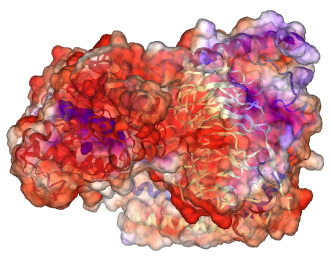

## --> Describe the electrostatic potential on receptor-binding interface of the G alpha subunit and G beta subunit.

## --> Describe the electrostatic potential on the GTP binding site. The GTP binding site is located between the two main domains of the G alpha subunit.

In [ ]:
view = create_widget('04/CF.pqr')
create_colored_surface(view)
create_isosurfaces(view)
view.display(gui=True)

## --> Orient the complex so that receptor is on top, the alpha subunit is on the left, and beta subunit on the right, like the image below. Hide isosurfaces. Take a screenshot and post it in your assignment on Canvas.

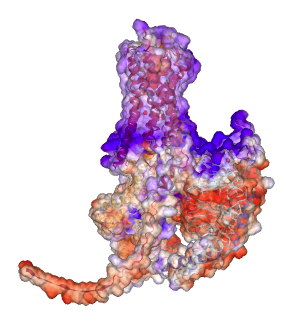

## --> Describe the electrostatic potential at the receptor-G protein binding interface.